In [6]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
# import rapids_singlecell as rsc
import scanpy as sc
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans

import sys
sys.path.append('../../..')
from libraries.clinical import load_clinical
from libraries.data_processing import *


In [2]:
adata = ad.read_h5ad('./03_LUAD_markers_clustered_2p0_4slides_with_phenotypes.h5ad')
adata

AnnData object with n_obs × n_vars = 2670923 × 26
    obs: 'core_ID', 'CellX', 'CellY', 'TMA', 'samples', 'leiden_0.5', 'leiden_0.6', 'leiden_0.8', 'leiden_1.0', 'leiden_1.5', 'leiden_2.0', 'cell_lineage', 'immune_lineage'
    uns: 'TMA_colors', 'leiden', 'leiden_0.5_colors', 'leiden_0.6_colors', 'leiden_0.8_colors', 'leiden_1.0_colors', 'leiden_1.5_colors', 'leiden_2.0_colors', 'nn_leiden', 'umap'
    obsm: 'X_umap'
    obsp: 'nn_leiden_connectivities', 'nn_leiden_distances'

In [43]:
adata.var_names

Index(['CD105_z', 'CD31_z', 'FAP_z', 'CD20_z', 'CD68_z', 'CD38_z', 'CD45_z',
       'Podoplanin_z', 'GATA6_z', 'HLA-DR_z', 'COL1A_z', 'CA9_z', 'CD8_z',
       'SMA_z', 'DECORIN_z', 'ECAD_z', 'CD4_z', 'GREM1_z', 'COLIV_z', 'NCAD_z',
       'CKPAN_z', 'LIF_z', 'S100A4_z', 'Vimentin_z', 'IL6_z', 'HNF4A_z'],
      dtype='object')

In [44]:
adata_stroma = adata[adata.obs['cell_lineage'] == 'stroma']

stromal_markers = ['CD31_z', 'COLIV_z', 'LIF_z', 'FAP_z', 'SMA_z', 'HLA-DR_z', 'IL6_z', 'Vimentin_z', 'Podoplanin_z', 'DECORIN_z', 'COL1A_z', 'S100A4_z']
# stromal_markers = ['CD31_z', 'COLIV_z', 'NCAD_z', 'LIF_z', 'FAP_z', 'SMA_z', 'HLA-DR_z', 'IL6_z', 'Vimentin_z', 'Podoplanin_z', 'DECORIN_z', 'COL1A_z']

adata_stroma = adata_stroma[:, adata_stroma.var_names.isin(stromal_markers)]
adata_stroma.var_names = [var.split("_")[0] for var in adata_stroma.var_names]

adata_stroma

AnnData object with n_obs × n_vars = 595491 × 12
    obs: 'core_ID', 'CellX', 'CellY', 'TMA', 'samples', 'leiden_0.5', 'leiden_0.6', 'leiden_0.8', 'leiden_1.0', 'leiden_1.5', 'leiden_2.0', 'cell_lineage', 'immune_lineage'
    uns: 'TMA_colors', 'leiden', 'leiden_0.5_colors', 'leiden_0.6_colors', 'leiden_0.8_colors', 'leiden_1.0_colors', 'leiden_1.5_colors', 'leiden_2.0_colors', 'nn_leiden', 'umap'
    obsm: 'X_umap'
    obsp: 'nn_leiden_connectivities', 'nn_leiden_distances'

In [45]:
adata_stroma.var_names

Index(['CD31', 'FAP', 'Podoplanin', 'HLA-DR', 'COL1A', 'SMA', 'DECORIN',
       'COLIV', 'LIF', 'S100A4', 'Vimentin', 'IL6'],
      dtype='object')

In [53]:
rsc.pp.neighbors(adata_stroma, n_neighbors=20, metric='euclidean', key_added='nn_leiden', random_state=42)
rsc.tl.umap(adata_stroma, min_dist=0.5, spread=1.0, n_components=2, neighbors_key='nn_leiden')

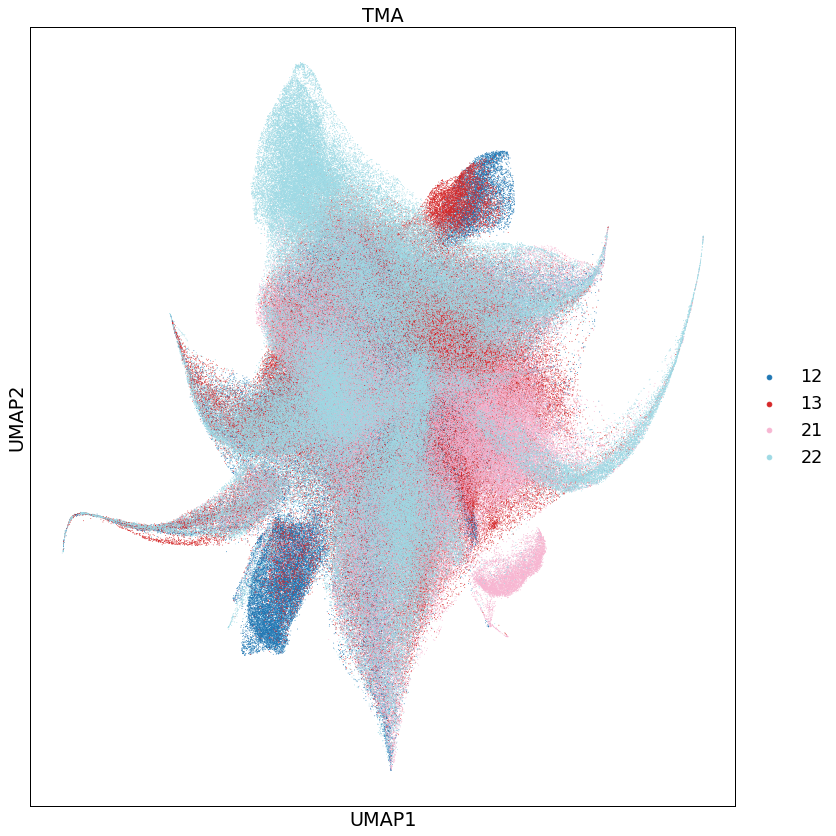

In [54]:
fig, ax = plt.subplots(figsize=(12,12))

sc.pl.umap(adata=adata_stroma, color='TMA', palette='tab20', size=3, ax=ax, show=False)

plt.tight_layout()
plt.show()

In [55]:
resolutions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

for resolution in resolutions:
    rsc.tl.leiden(adata=adata_stroma, resolution=resolution, key_added=f'stroma_leiden_{resolution}', neighbors_key='nn_leiden')


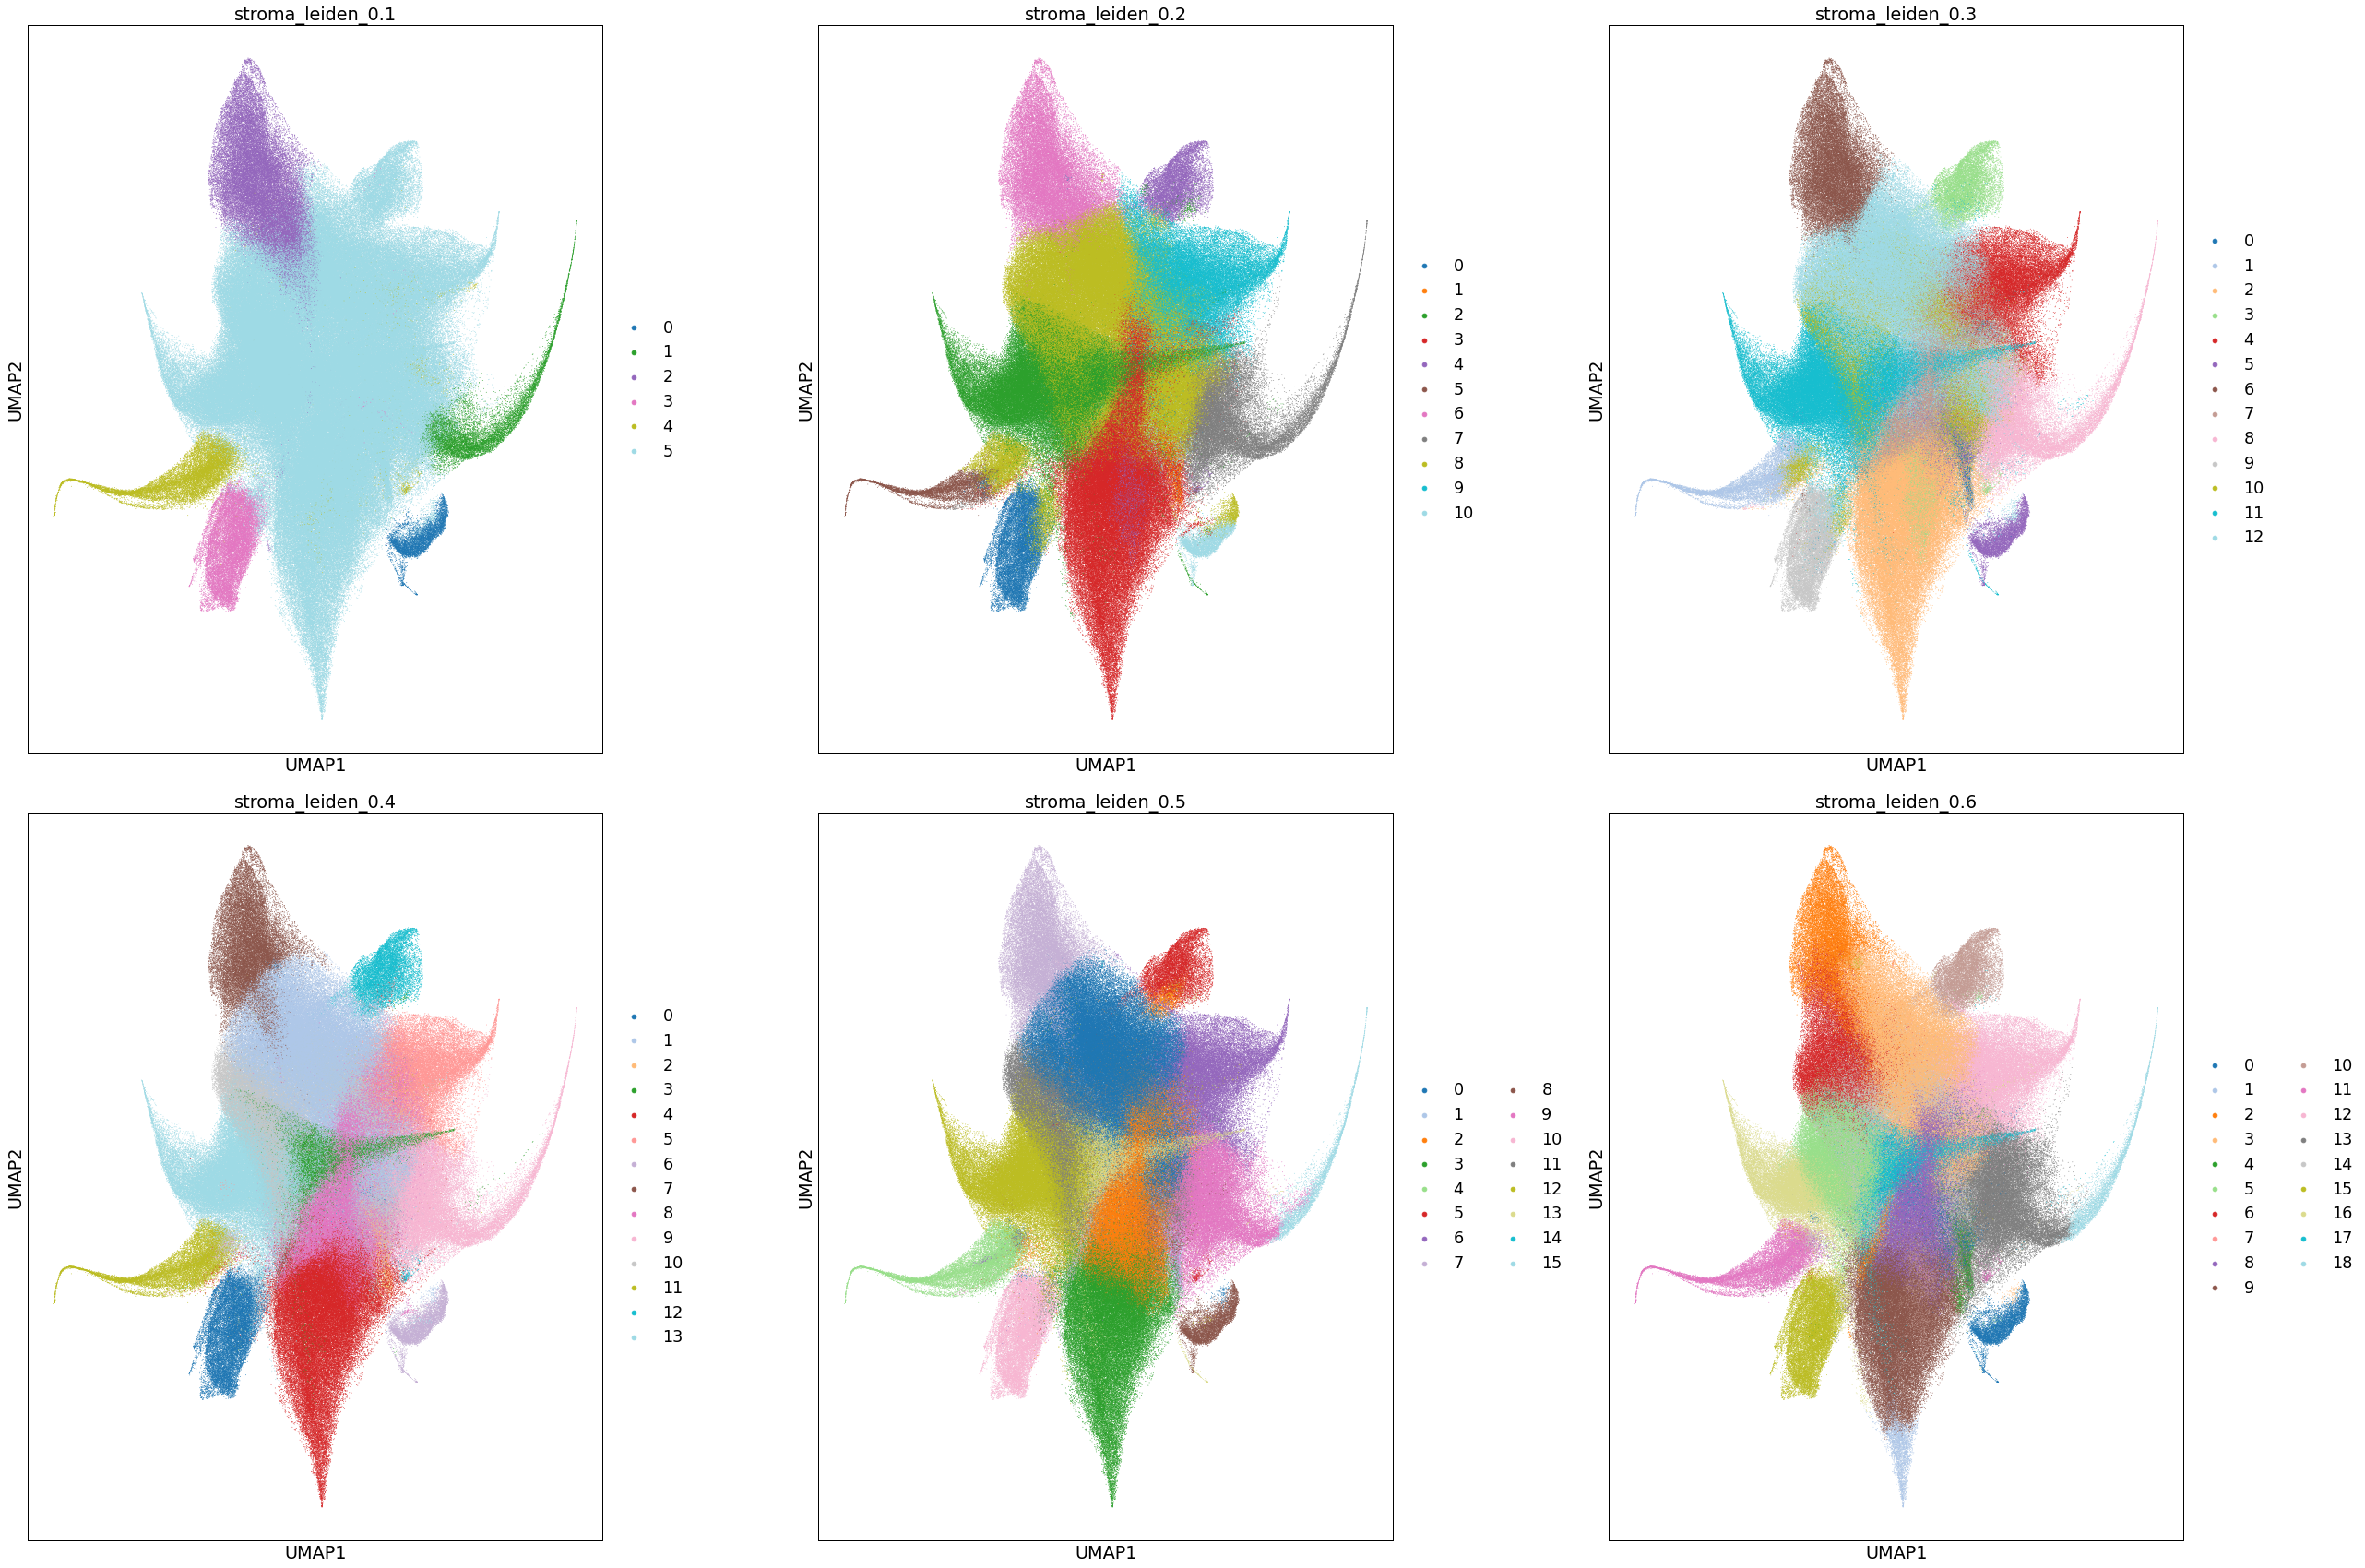

In [56]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(36,24))
axs = axs.flatten()

for i, resolution in enumerate(resolutions):
    sc.pl.umap(adata=adata_stroma, color=f'stroma_leiden_{resolution}', palette='tab20', size=3, ax=axs[i], show=False)

plt.tight_layout()
plt.show()

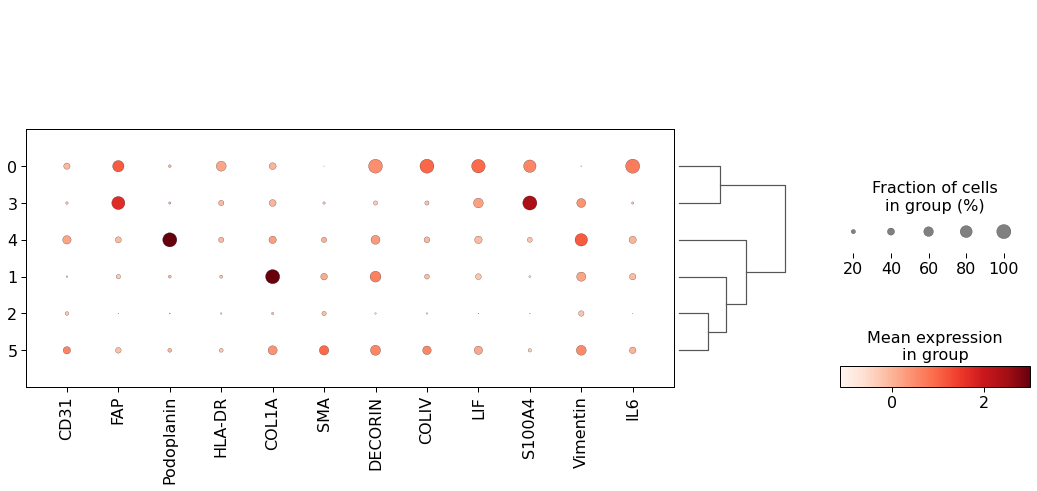

In [57]:
groupby = 'stroma_leiden_0.1'

sns.set_context("paper", font_scale=2.0)

sc.tl.dendrogram(adata=adata_stroma, groupby=groupby)
fig, ax = plt.subplots(figsize=(18,7))
sc.pl.dotplot(adata_stroma, var_names=adata_stroma.var_names, groupby=groupby, dendrogram=True, ax=ax, vmax=3)

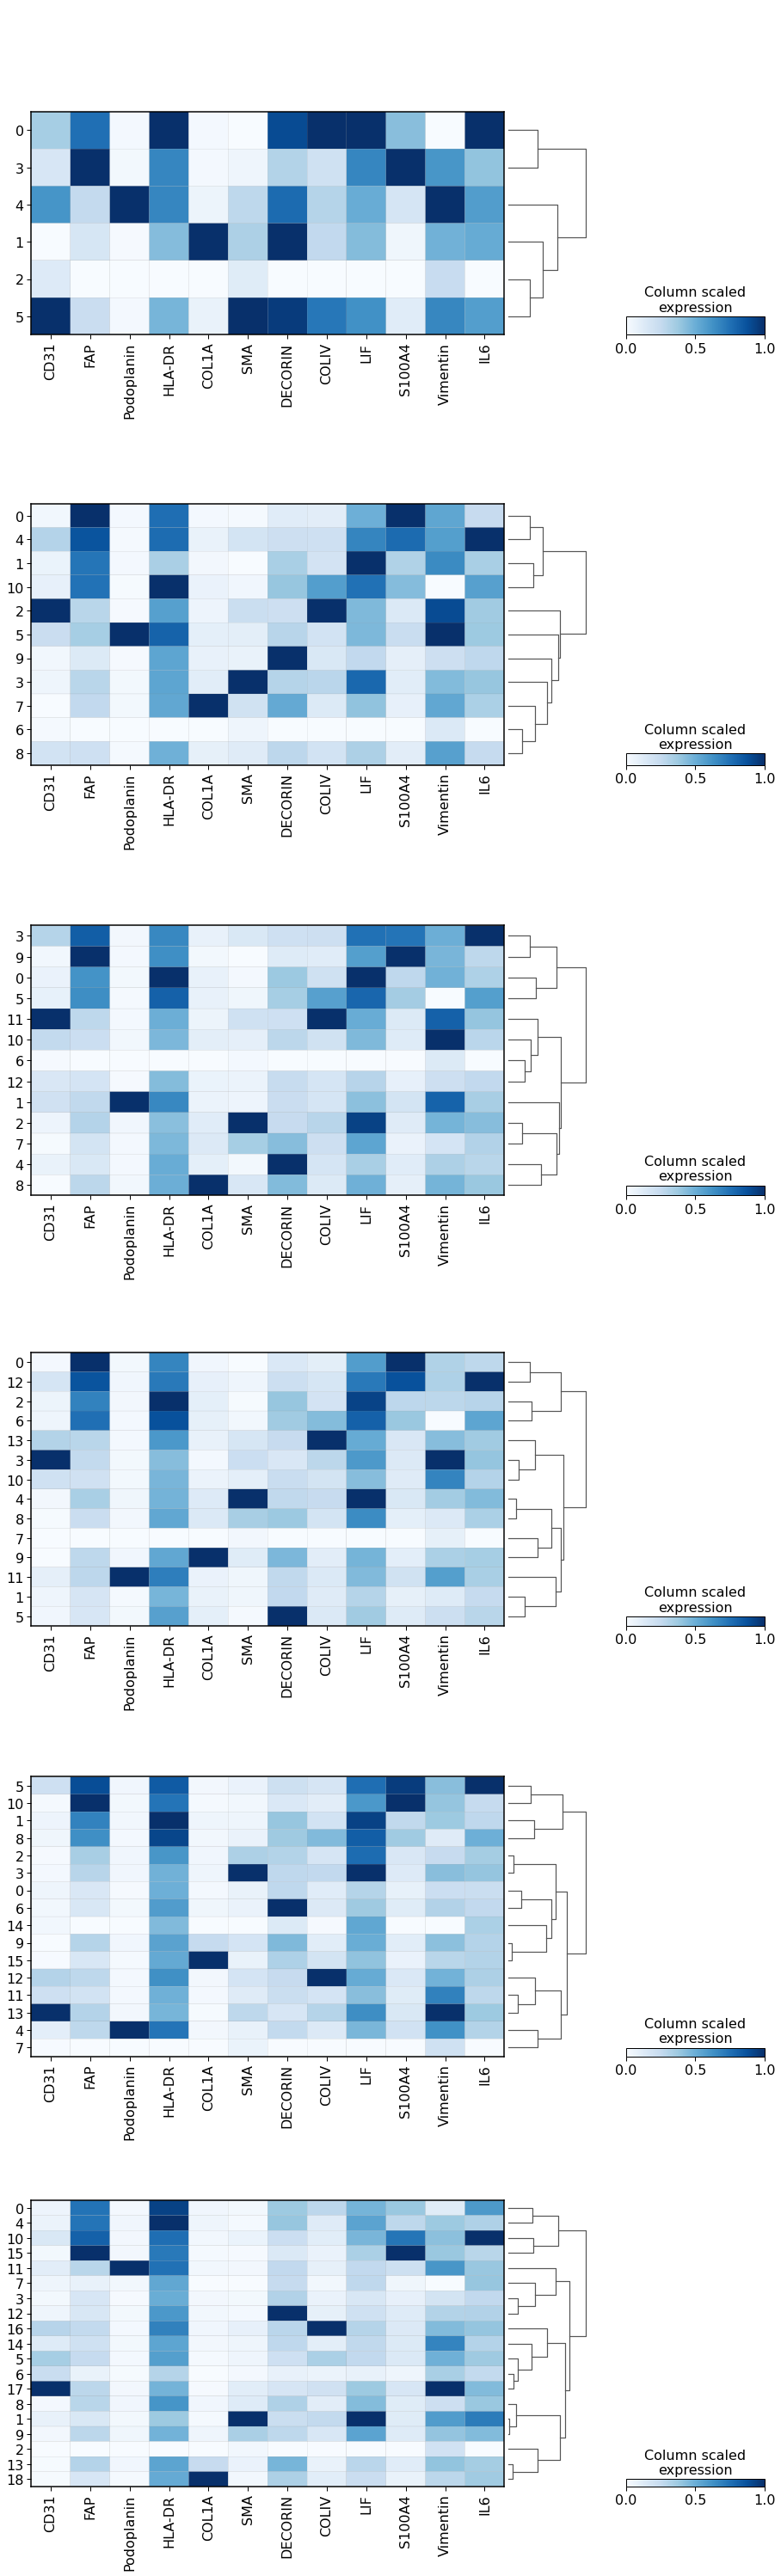

In [58]:
fig, axs = plt.subplots(nrows=6, ncols=1, figsize=(13,7*6))
axs = axs.flatten()

for i, resolution in enumerate(resolutions):
    groupby = f'stroma_leiden_{resolution}'
    sc.tl.dendrogram(adata=adata_stroma, groupby=groupby)
    sc.pl.matrixplot(adata_stroma, var_names=adata_stroma.var_names, groupby=groupby, dendrogram=True, cmap='Blues', vmin=0, vmax=1, standard_scale='var', colorbar_title="Column scaled\nexpression", show=False, ax=axs[i])
# sc.pl.matrixplot(adata_stroma, var_names=adata_stroma.var_names, groupby='stroma_leiden_0.5', dendrogram=True, cmap='Blues', standard_scale='var', colorbar_title="Column scaled\nexpression", figsize=(13,7))

plt.tight_layout()
plt.show()

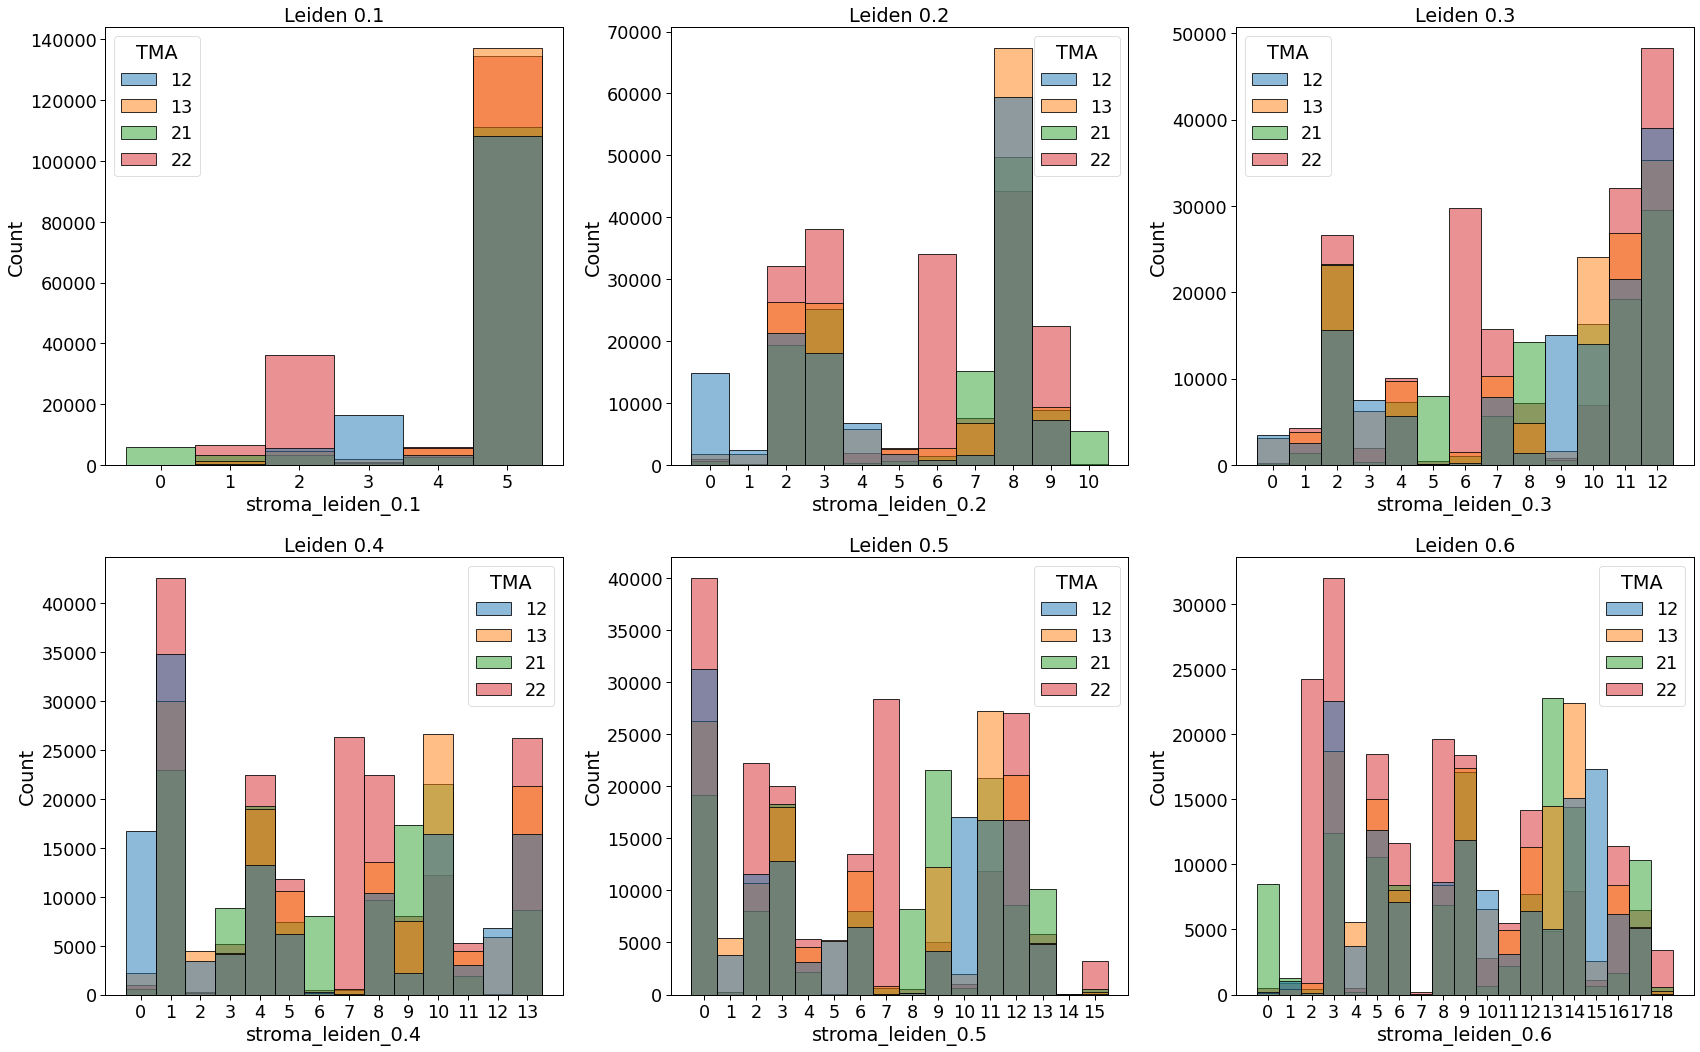

In [59]:
# CLuster frequency on TMAs -- are some TMA specific? Not really, but some predominance. 
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(24,15))
axs = axs.flatten()
for i, resolution in enumerate(resolutions):
    sns.histplot(data=adata_stroma.obs, x=f'stroma_leiden_{resolution}', hue='TMA', ax=axs[i])
    axs[i].set_title(f'Leiden {resolution}')

plt.tight_layout()
plt.show()

In [ ]:

kmeans = MiniBatchKMeans(n_clusters=6, random_state=0)
adata_stroma.obs['kmeans'] = kmeans.fit_predict(X=adata_stroma.X)
adata_stroma.obs

,core_ID,CellX,CellY,TMA,samples,leiden_0.5,leiden_0.6,leiden_0.8,leiden_1.0,leiden_1.5,leiden_2.0,cell_lineage,immune_lineage,stroma_leiden_0.1,stroma_leiden_0.2,stroma_leiden_0.3,stroma_leiden_0.4,stroma_leiden_0.5,stroma_leiden_0.6,kmeans
cell_0,12-15-J,2396.8,6263.1,12,ACA_0662,21,26,25,31,45,56,stroma,NaN,5,8,12,1,0,6,1
cell_16,12-15-J,2576.0,6276.9,12,ACA_0662,21,26,25,31,45,85,stroma,NaN,5,2,2,4,3,9,2
cell_23,12-15-J,2384.6,6281.8,12,ACA_0662,21,26,25,31,45,56,stroma,NaN,5,8,11,13,12,5,2
cell_32,12-15-J,2508.0,6289.9,12,ACA_0662,21,26,25,31,45,56,stroma,NaN,5,2,11,3,13,17,0
cell_36,12-15-J,2392.0,6290.7,12,ACA_0662,21,26,25,31,45,56,stroma,NaN,5,8,12,10,11,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cell_2670889,22-15-J,17466.5,21102.6,22,ACA_1069,21,26,25,31,65,85,stroma,NaN,5,3,2,4,3,17,2
cell_2670895,22-15-J,17132.9,20327.1,22,ACA_1069,46,55,28,74,97,23,stroma,NaN,2,6,6,7,7,2,1
cell_2670899,22-15-J,16799.7,20627.6,22,ACA_1069,21,26,25,31,45,56,stroma,NaN,5,2,11,13,12,17,0
cell_2670903,22-15-J,17811.9,20821.9,22,ACA_1069,46,55,33,74,97,23,stroma,NaN,2,6,6,7,7,2,1


In [44]:
# Review on QuPath
adata_stroma.obs[adata_stroma.obs['TMA'] == '22'][['CellX', 'CellY', 'stroma_leiden_0.5']].to_csv('./tma_22_stromal_clusters.csv')

In [278]:
adata_stroma.write_h5ad('./04_adata_stroma_clustered_0p1-0p6_kmeans.h5ad')

In [3]:
adata_stroma = ad.read_h5ad('./04_adata_stroma_clustered_0p1-0p6_kmeans.h5ad')
adata_stroma.obs

,core_ID,CellX,CellY,TMA,samples,leiden_0.5,leiden_0.6,leiden_0.8,leiden_1.0,leiden_1.5,leiden_2.0,cell_lineage,immune_lineage,stroma_leiden_0.1,stroma_leiden_0.2,stroma_leiden_0.3,stroma_leiden_0.4,stroma_leiden_0.5,stroma_leiden_0.6,kmeans
cell_0,12-15-J,2396.8,6263.1,12,ACA_0662,21,26,25,31,45,56,stroma,NaN,5,8,12,1,0,6,1
cell_16,12-15-J,2576.0,6276.9,12,ACA_0662,21,26,25,31,45,85,stroma,NaN,5,2,2,4,3,9,2
cell_23,12-15-J,2384.6,6281.8,12,ACA_0662,21,26,25,31,45,56,stroma,NaN,5,8,11,13,12,5,2
cell_32,12-15-J,2508.0,6289.9,12,ACA_0662,21,26,25,31,45,56,stroma,NaN,5,2,11,3,13,17,0
cell_36,12-15-J,2392.0,6290.7,12,ACA_0662,21,26,25,31,45,56,stroma,NaN,5,8,12,10,11,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cell_2670889,22-15-J,17466.5,21102.6,22,ACA_1069,21,26,25,31,65,85,stroma,NaN,5,3,2,4,3,17,2
cell_2670895,22-15-J,17132.9,20327.1,22,ACA_1069,46,55,28,74,97,23,stroma,NaN,2,6,6,7,7,2,1
cell_2670899,22-15-J,16799.7,20627.6,22,ACA_1069,21,26,25,31,45,56,stroma,NaN,5,2,11,13,12,17,0
cell_2670903,22-15-J,17811.9,20821.9,22,ACA_1069,46,55,33,74,97,23,stroma,NaN,2,6,6,7,7,2,1


In [4]:
adata_stroma.obs

,core_ID,CellX,CellY,TMA,samples,leiden_0.5,leiden_0.6,leiden_0.8,leiden_1.0,leiden_1.5,leiden_2.0,cell_lineage,immune_lineage,stroma_leiden_0.1,stroma_leiden_0.2,stroma_leiden_0.3,stroma_leiden_0.4,stroma_leiden_0.5,stroma_leiden_0.6,kmeans
cell_0,12-15-J,2396.8,6263.1,12,ACA_0662,21,26,25,31,45,56,stroma,NaN,5,8,12,1,0,6,1
cell_16,12-15-J,2576.0,6276.9,12,ACA_0662,21,26,25,31,45,85,stroma,NaN,5,2,2,4,3,9,2
cell_23,12-15-J,2384.6,6281.8,12,ACA_0662,21,26,25,31,45,56,stroma,NaN,5,8,11,13,12,5,2
cell_32,12-15-J,2508.0,6289.9,12,ACA_0662,21,26,25,31,45,56,stroma,NaN,5,2,11,3,13,17,0
cell_36,12-15-J,2392.0,6290.7,12,ACA_0662,21,26,25,31,45,56,stroma,NaN,5,8,12,10,11,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cell_2670889,22-15-J,17466.5,21102.6,22,ACA_1069,21,26,25,31,65,85,stroma,NaN,5,3,2,4,3,17,2
cell_2670895,22-15-J,17132.9,20327.1,22,ACA_1069,46,55,28,74,97,23,stroma,NaN,2,6,6,7,7,2,1
cell_2670899,22-15-J,16799.7,20627.6,22,ACA_1069,21,26,25,31,45,56,stroma,NaN,5,2,11,13,12,17,0
cell_2670903,22-15-J,17811.9,20821.9,22,ACA_1069,46,55,33,74,97,23,stroma,NaN,2,6,6,7,7,2,1


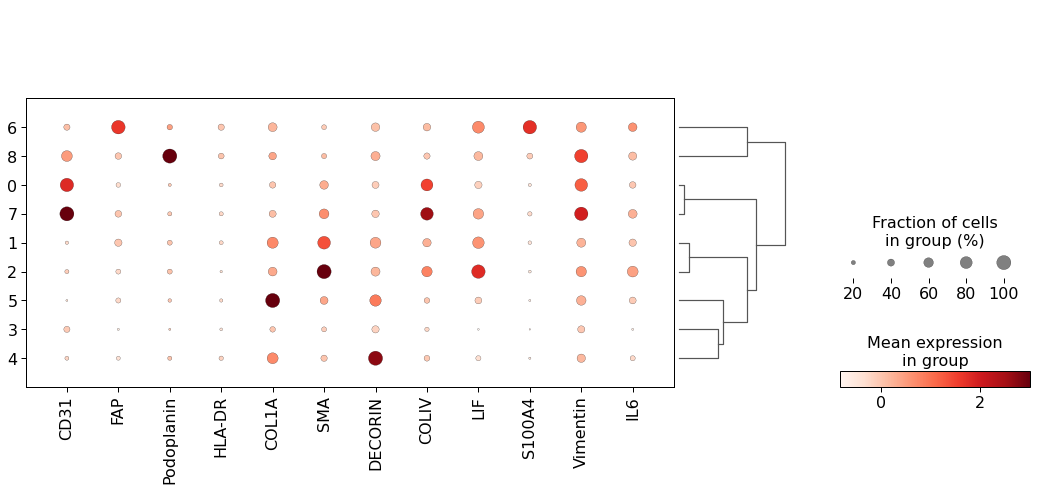

In [8]:
sns.set_context("paper", font_scale=2.0)

n_clusters = 9
kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=0)
groupby = f'kmeans_{n_clusters}'

adata_stroma.obs[groupby] = kmeans.fit_predict(X=adata_stroma.X)
adata_stroma.obs

adata_stroma.obs[groupby] = adata_stroma.obs[groupby].astype('category')


sc.tl.dendrogram(adata=adata_stroma, groupby=groupby)
fig, ax = plt.subplots(figsize=(18,7))
sc.pl.dotplot(adata_stroma, var_names=adata_stroma.var_names, groupby=groupby, dendrogram=True, ax=ax, vmax=3)

In [9]:
adata_stroma.obs['kmeans_9'].value_counts()

3    160192
1    141579
0     90097
4     77479
6     47500
2     34818
7     29266
5     11297
8      3263
Name: kmeans_9, dtype: int64

In [10]:
# CLusters 0 and 7 on kmeans k = 8 and k = 9 are the same cells, not meaningful so collapse these

adata_stroma.obs['kmeans_9'] = adata_stroma.obs['kmeans_9'].replace({7:0})
adata_stroma.obs['kmeans_9'].value_counts()

3    160192
1    141579
0    119363
4     77479
6     47500
2     34818
5     11297
8      3263
Name: kmeans_9, dtype: int64

In [11]:
# fibroblast_phenotype_dict = {0:'Endothelium', 1:'Fibroblast 1', 2:'Fibroblast 2', 3:'Fibroblast 3', 4:'Fibroblast 4', 5:'Fibrpblast 5', 6:'Fibroblast 6', 8:'Fibroblast 7'}
# fibroblast_phenotype_dict = {0:'Endothelium', 1:u'F\u2081', 2:'F\u2082', 3:'F\u2083', 4:'F\u2084', 5:'F\u2085', 6:'F\u2086', 8:'F\u2087'}
fibroblast_phenotype_dict = {0:'Endothelium', 1:r'$SMA_{med}COL1A_{med}$', 2:r'$SMA_{high}LIF_{high}$', 3:'Unclassifiable', 
                             4:r'$DCN_{high}COL1A_{med}$', 5:r'$COL1A_{high}DCN_{med}$', 6:r'$S100A4_{high}FAP_{high}$', 8:r'$PDPN_{high}$'}

adata_stroma.obs['text_phenotype'] = adata_stroma.obs[groupby].map(fibroblast_phenotype_dict)
adata_stroma.obs

,core_ID,CellX,CellY,TMA,samples,leiden_0.5,leiden_0.6,leiden_0.8,leiden_1.0,leiden_1.5,...,immune_lineage,stroma_leiden_0.1,stroma_leiden_0.2,stroma_leiden_0.3,stroma_leiden_0.4,stroma_leiden_0.5,stroma_leiden_0.6,kmeans,kmeans_9,text_phenotype
cell_0,12-15-J,2396.8,6263.1,12,ACA_0662,21,26,25,31,45,...,NaN,5,8,12,1,0,6,1,3,Unclassifiable
cell_16,12-15-J,2576.0,6276.9,12,ACA_0662,21,26,25,31,45,...,NaN,5,2,2,4,3,9,2,2,$SMA_{high}LIF_{high}$
cell_23,12-15-J,2384.6,6281.8,12,ACA_0662,21,26,25,31,45,...,NaN,5,8,11,13,12,5,2,1,$SMA_{med}COL1A_{med}$
cell_32,12-15-J,2508.0,6289.9,12,ACA_0662,21,26,25,31,45,...,NaN,5,2,11,3,13,17,0,0,Endothelium
cell_36,12-15-J,2392.0,6290.7,12,ACA_0662,21,26,25,31,45,...,NaN,5,8,12,10,11,5,1,0,Endothelium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cell_2670889,22-15-J,17466.5,21102.6,22,ACA_1069,21,26,25,31,65,...,NaN,5,3,2,4,3,17,2,2,$SMA_{high}LIF_{high}$
cell_2670895,22-15-J,17132.9,20327.1,22,ACA_1069,46,55,28,74,97,...,NaN,2,6,6,7,7,2,1,3,Unclassifiable
cell_2670899,22-15-J,16799.7,20627.6,22,ACA_1069,21,26,25,31,45,...,NaN,5,2,11,13,12,17,0,0,Endothelium
cell_2670903,22-15-J,17811.9,20821.9,22,ACA_1069,46,55,33,74,97,...,NaN,2,6,6,7,7,2,1,3,Unclassifiable


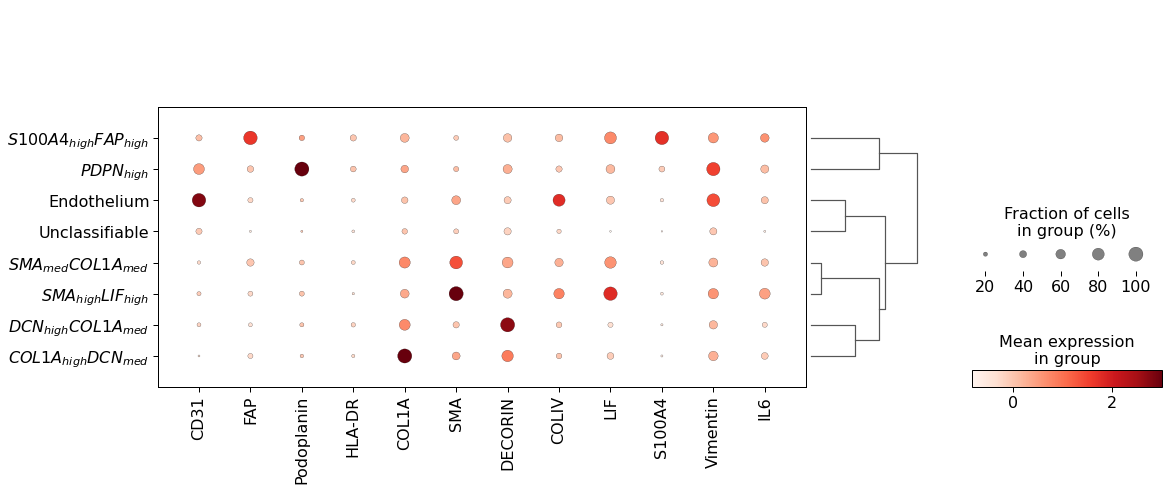

In [12]:
sc.tl.dendrogram(adata=adata_stroma, groupby='text_phenotype')
fig, ax = plt.subplots(figsize=(18,7))
sc.pl.dotplot(adata_stroma, var_names=adata_stroma.var_names, groupby='text_phenotype', dendrogram=True, ax=ax, vmax=3)

In [13]:
adata_stroma.obs_names = [f'Cell_{i}' for i in range(len(adata_stroma.obs_names))]
adata_stroma = adata_stroma[adata_stroma.obs['text_phenotype'] != 'Unclassifiable']

In [14]:
adata_stroma.obs[groupby].value_counts()

1    141579
0    119363
4     77479
6     47500
2     34818
5     11297
8      3263
Name: kmeans_9, dtype: int64

/mnt/cephfs/home/users/krakovic/.conda/envs/scpy/lib/python3.10/site-packages/scanpy/tools/_dendrogram.py:190: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = dat


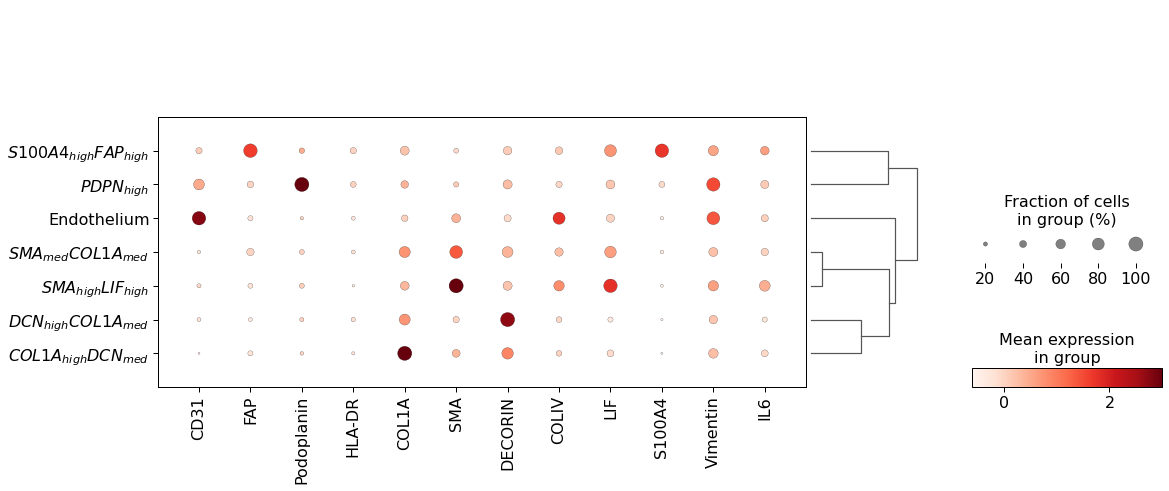

In [15]:
sc.tl.dendrogram(adata=adata_stroma, groupby='text_phenotype')
fig, ax = plt.subplots(figsize=(18,7))
sc.pl.dotplot(adata_stroma, var_names=adata_stroma.var_names, groupby='text_phenotype', dendrogram=True, ax=ax, vmax=3)

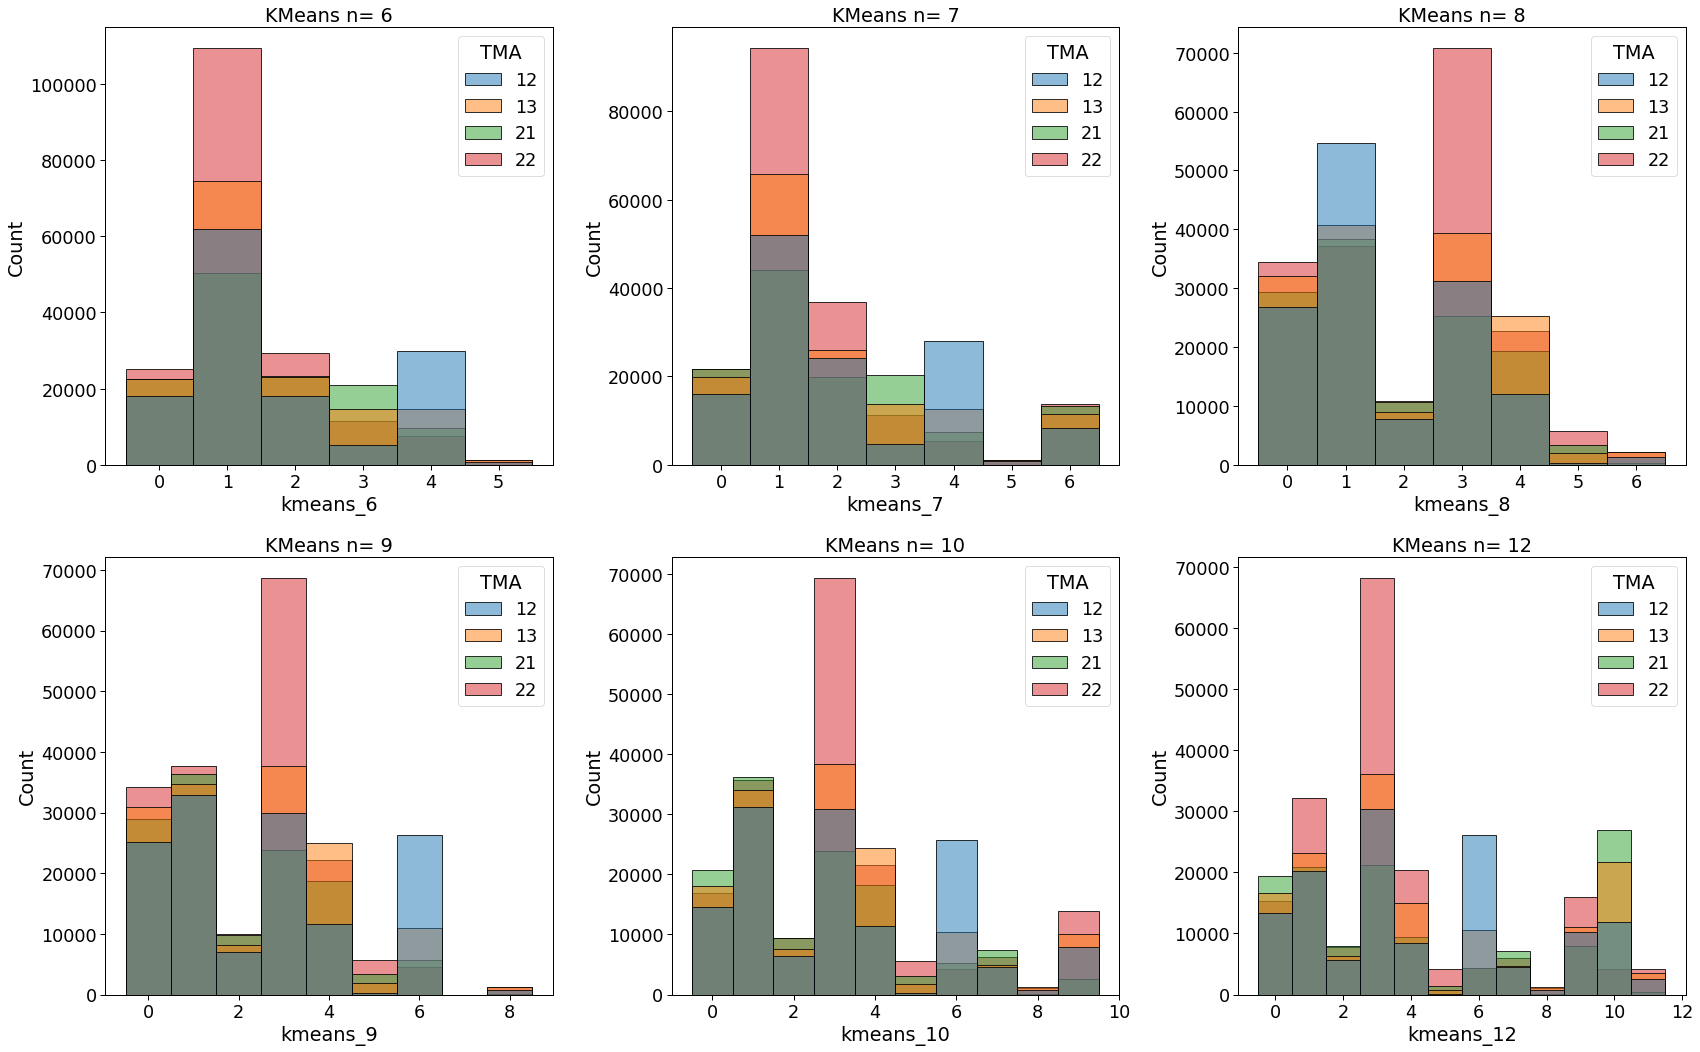

In [313]:
# CLuster frequency on TMAs -- are some TMA specific? Not really, but some predominance. 
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(24,15))
axs = axs.flatten()
for i, resolution in enumerate([6, 7, 8, 9, 10, 12]):
    sns.histplot(data=adata_stroma.obs, x=f'kmeans_{resolution}', hue='TMA', ax=axs[i])
    axs[i].set_title(f'KMeans n= {resolution}')

plt.tight_layout()
plt.show()

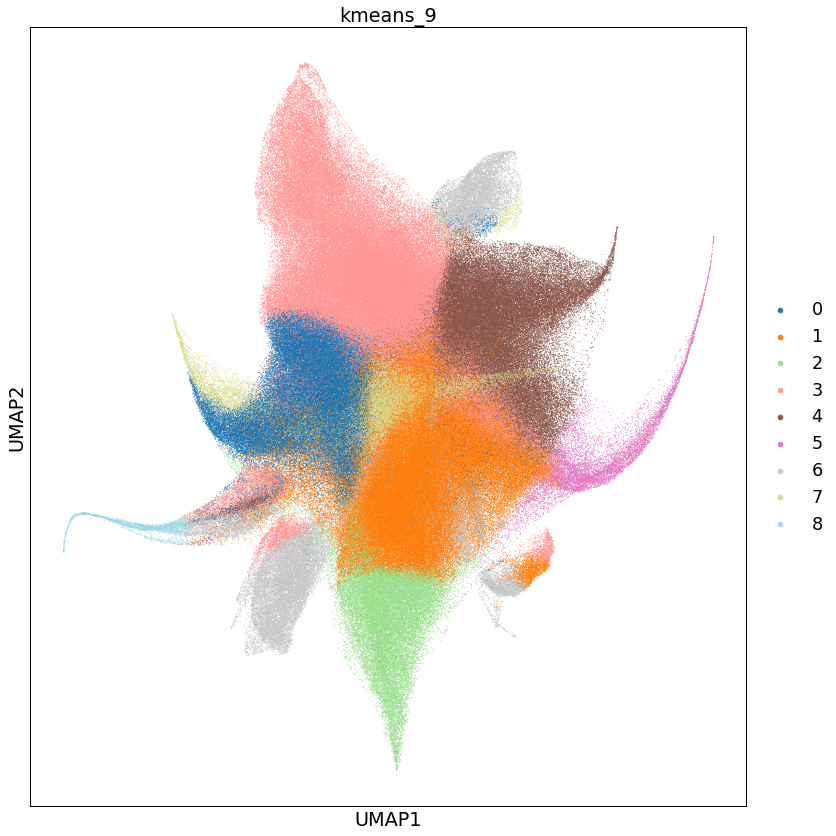

In [40]:
fig, ax = plt.subplots(figsize=(12,12))

sc.pl.umap(adata=adata_stroma, color=groupby, palette='tab20', size=3, ax=ax, show=False)

plt.tight_layout()
plt.show()

In [124]:
adata_stroma.write_h5ad('./04_adata_stroma_clustered_kmeans_9_withtext.h5ad')